# generate regression datasets

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression

In [23]:
X,y = make_regression(
    n_samples= 300,
    n_features= 8,
    noise = 30,
    random_state= 7
)

In [24]:
print(X.shape[1]) # print column
print(X.shape[0]) # print row
print(X)
print(y)

8
300
[[-0.56611074  0.21441575 -1.48709026 ...  0.69270296 -0.21959284
   2.07603212]
 [-0.31400204  0.13301982 -1.22691767 ...  0.44104058  0.20467211
  -0.38019573]
 [-1.5361023  -0.28110791  0.01448894 ... -1.24351751 -0.82346008
  -0.27338281]
 ...
 [ 0.98251083  0.50813759  0.75163555 ... -0.24335206 -1.61460869
   0.50398546]
 [-1.26019012 -0.94382838  0.17565555 ...  0.25542802  0.25570463
   0.52989449]
 [-0.16736253  1.27466217  1.52818462 ... -0.40443767 -2.43408907
   1.17381077]]
[-2.60265736e+01  1.52156538e+01 -3.40059710e+02 -2.19098184e+02
 -1.07876280e+02 -1.17986383e+02  1.10316764e-01  1.60155645e+02
  2.97209216e+02 -8.03339147e+01  2.98148101e+02 -1.39315056e+02
 -1.93246296e+02 -1.01564357e+02  6.26746959e+01 -1.62624449e+02
  9.54296429e+01  5.02337021e+01 -8.84733641e+01 -1.45186211e+02
  1.41302582e+02 -3.31953742e+02 -8.13312508e+01  2.43918939e+02
 -1.74387044e+02 -1.58300100e+02 -1.26055031e+02  8.27468385e+01
  2.66277329e+01 -4.06456307e+02  1.48856543e+0

# Scatter Plot

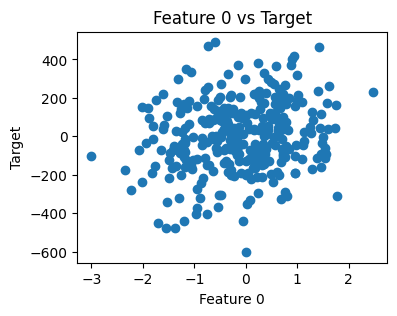

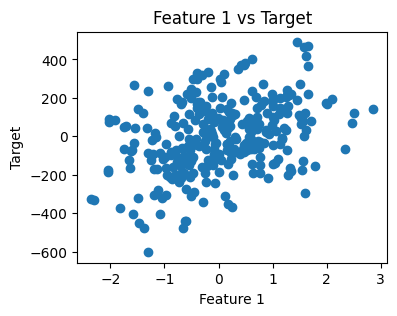

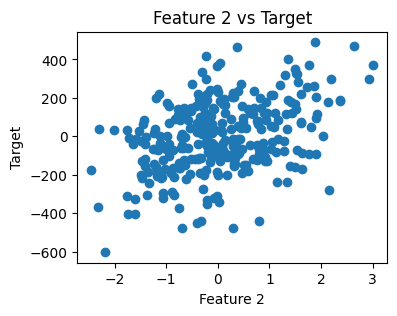

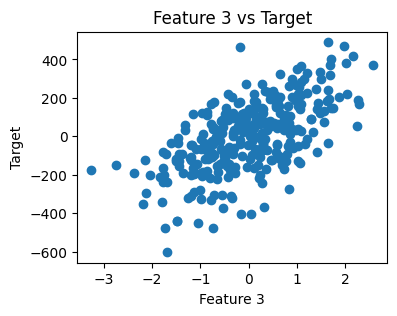

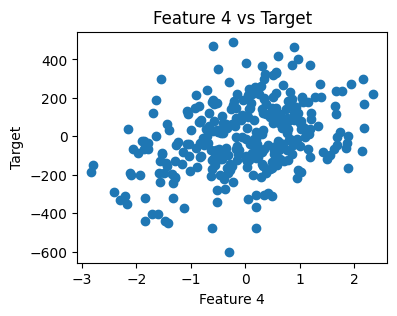

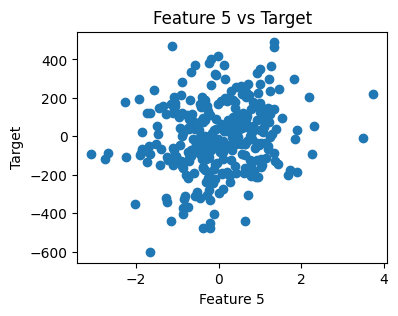

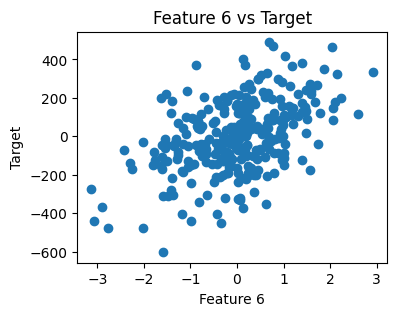

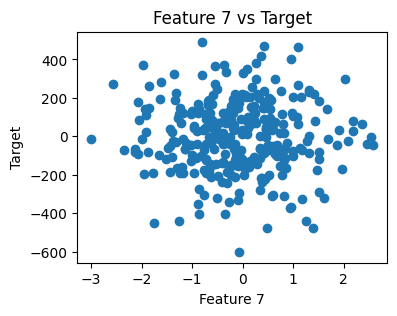

In [25]:
import matplotlib.pyplot as plt

for i in range(X.shape[1]):
    plt.figure(figsize=(4,3))
    plt.scatter(X[:,i], y)
    plt.xlabel(f"Feature {i}")
    plt.ylabel("Target")
    plt.title(f"Feature {i} vs Target")
    plt.show()

# Multiple_Linear Regression

In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size= 0.3,
    random_state= 42
)

In [34]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train,y_train)

print(f"Intercept_ : {reg.intercept_}")
print(f"Coefficients_ : {reg.coef_}")

Intercept_ : 3.586132372625741
Coefficients_ : [29.6494843  64.33020208 64.48479087 99.5582165  49.02333259 33.94852317
 87.14362711  8.96591488]


## metrics

In [37]:
from sklearn.metrics import r2_score
y_pred = reg.predict(X_test)
print(f"r2 Score : {r2_score(y_test,y_pred)}")

r2 Score : 0.9714653081071041


# RidgeReg

### alpha=10

In [40]:
from sklearn.linear_model import Ridge
RReg = Ridge(alpha=10)
RReg.fit(X_train,y_train)
print(f"Intercept_ : {RReg.intercept_}")
print(f"Coefficient_ : {RReg.coef_}")

Intercept_ : 3.376037927253803
Coefficient_ : [28.55374831 61.82982592 62.0204915  95.60312796 47.67765862 32.6870189
 83.15166478  8.20863764]


## alpha= 100

In [41]:
from sklearn.linear_model import Ridge
RReg = Ridge(alpha=100)
RReg.fit(X_train,y_train)
print(f"Intercept_ : {RReg.intercept_}")
print(f"Coefficient_ : {RReg.coef_}")

Intercept_ : 1.9968125908051366
Coefficient_ : [21.50653376 45.79507999 46.23997987 70.47666445 37.81293159 24.41567392
 59.02548611  4.27085246]


## plot to observe alpha

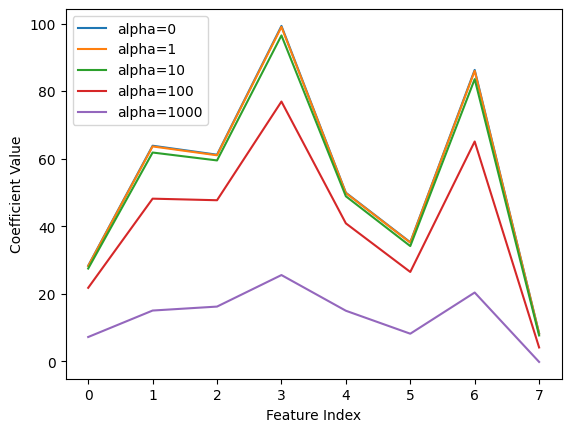

In [42]:
alphas = [0,1,10,100,1000]

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X,y)

    plt.plot(ridge.coef_, label=f"alpha={a}")

plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.legend()
plt.show()




 > Result:

    . Alpha=0 → large coefficients
    .Alpha=1000 → coefficients move toward zero

# Scratch

In [43]:
class MeraRidgeGD:

    def __init__(self,epochs,learning_rate,alpha):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):

        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        thetha = np.insert(self.coef_,0,self.intercept_)

        X_train = np.insert(X_train,0,1,axis=1)

        for i in range(self.epochs):
            thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
            thetha = thetha - self.learning_rate*thetha_der

        self.coef_ = thetha[1:]
        self.intercept_ = thetha[0]

    def predict(self,X_test):

        return np.dot(X_test,self.coef_) + self.intercept_

In [44]:
reg = MeraRidgeGD(epochs=500,alpha=0.001,learning_rate=0.005)

# metrics

In [45]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.9714656392947665
[29.64936753 64.32994273 64.48453552 99.55780323 49.02319475 33.9483932
 87.14320843  8.96583322]
3.5860929025734465
